In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))
print("Uploaded file:", filename)

df = pd.read_excel(filename)

print(df.head())
print("Shape:", df.shape)

Saving RELIANCE.NS_1973-05-08_2025-03-01.xlsx to RELIANCE.NS_1973-05-08_2025-03-01.xlsx
Uploaded file: RELIANCE.NS_1973-05-08_2025-03-01.xlsx
                        date      open      high       low     close  \
0  1996-01-01 00:00:00+05:30  7.319124  7.358397  7.270925  7.345901   
1  1996-01-02 00:00:00+05:30   7.32805  7.363753  7.235222  7.288776   
2  1996-01-03 00:00:00+05:30  7.408381  7.745775   7.32805  7.344116   
3  1996-01-04 00:00:00+05:30  7.274495  7.297702  7.178097   7.27628   
4  1996-01-05 00:00:00+05:30  7.247718  7.247718  7.163816  7.226296   

  adj_close     volume  
0  3.353593  104121369  
1  3.327513  168743308  
2  3.352778  209323879  
3  3.321809  216900264  
4   3.29899  166708467  
Shape: (7329, 7)


In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["close"] = pd.to_numeric(df["close"], errors="coerce")
df["volume"] = pd.to_numeric(df["volume"], errors="coerce")

df = df.dropna(subset=["date", "close", "volume"])
df = df.sort_values("date").reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print(df.head())
print(df.tail())

Cleaned dataset shape: (7324, 7)
                       date      open      high       low     close adj_close  \
0 1996-01-01 00:00:00+05:30  7.319124  7.358397  7.270925  7.345901  3.353593   
1 1996-01-02 00:00:00+05:30   7.32805  7.363753  7.235222  7.288776  3.327513   
2 1996-01-03 00:00:00+05:30  7.408381  7.745775   7.32805  7.344116  3.352778   
3 1996-01-04 00:00:00+05:30  7.274495  7.297702  7.178097  7.276280  3.321809   
4 1996-01-05 00:00:00+05:30  7.247718  7.247718  7.163816  7.226296   3.29899   

        volume  
0  104121369.0  
1  168743308.0  
2  209323879.0  
3  216900264.0  
4  166708467.0  
                          date         open         high          low  \
7319 2025-02-21 00:00:00+05:30  1228.699951         1240  1222.150024   
7320 2025-02-24 00:00:00+05:30  1216.550049      1223.25       1210.5   
7321 2025-02-25 00:00:00+05:30         1211         1221       1201.5   
7322 2025-02-27 00:00:00+05:30  1212.800049         1215  1200.650024   
7323 2025-02-

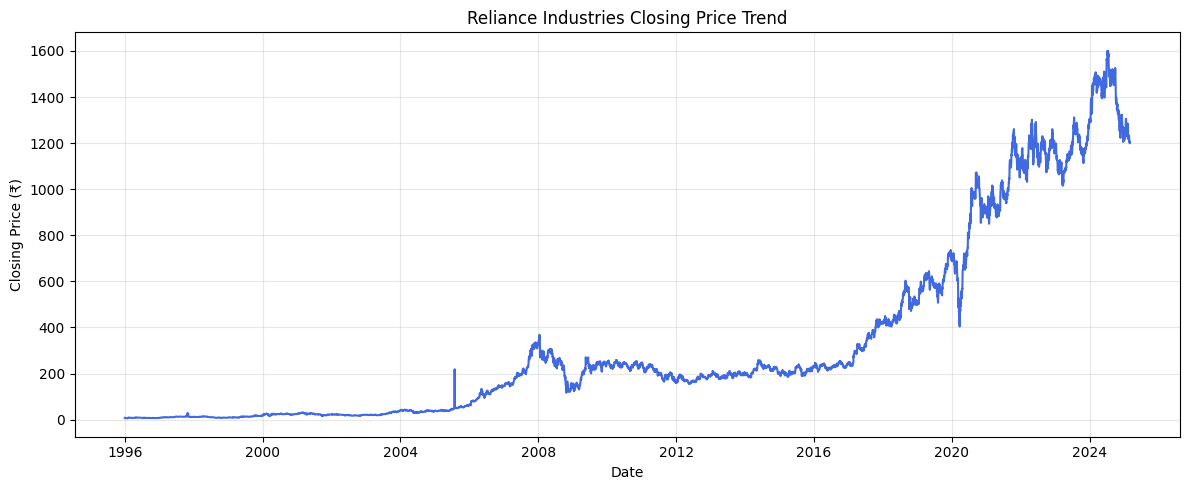

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["close"],
    color="royalblue",
    linewidth=1.5
)

plt.title("Reliance Industries Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

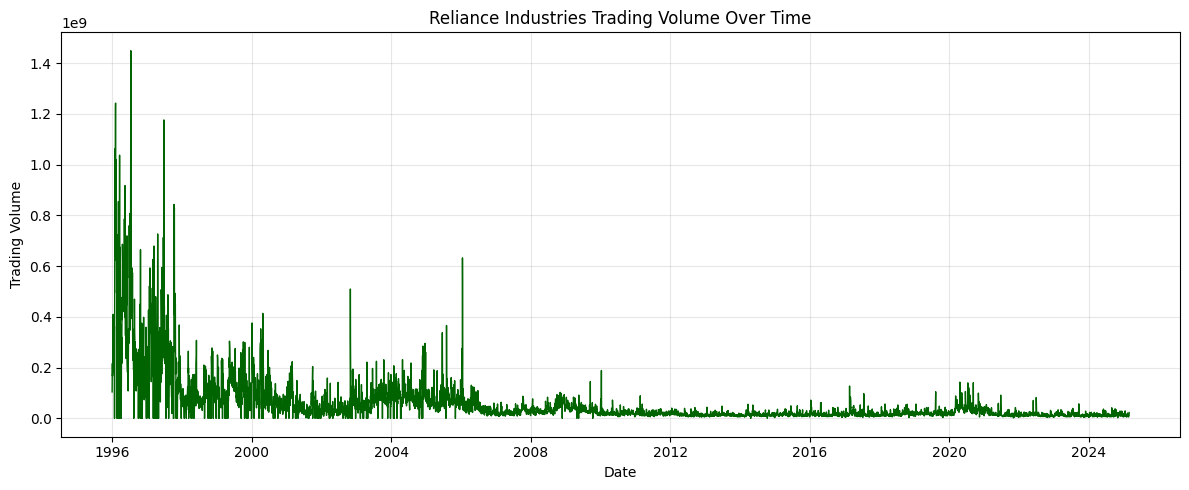

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["volume"],
    color="darkgreen",
    linewidth=1
)

plt.title("Reliance Industries Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

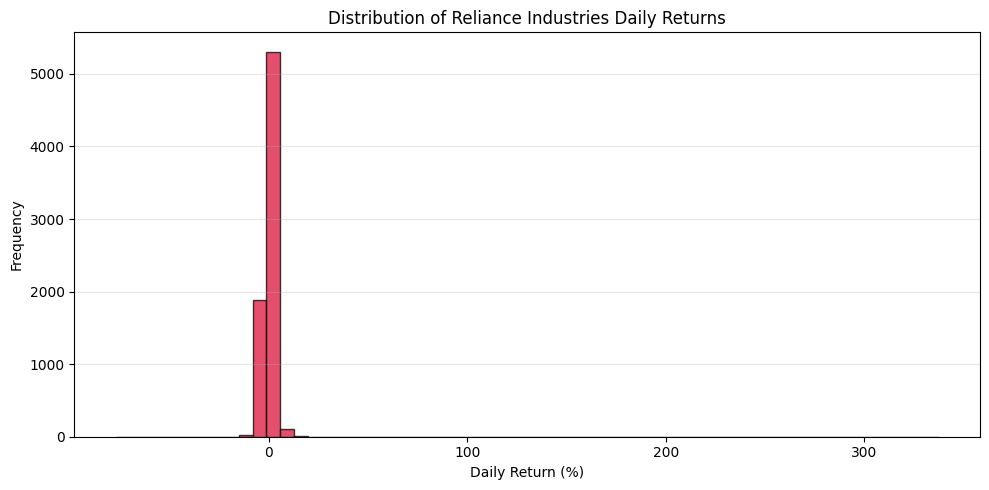

In [ ]:
import matplotlib.pyplot as plt

df["daily_return"] = df["close"].pct_change() * 100
df = df.dropna(subset=["daily_return"])

plt.figure(figsize=(10, 5))

plt.hist(
    df["daily_return"],
    bins=60,
    color="crimson",
    edgecolor="black",
    alpha=0.75
)

plt.title("Distribution of Reliance Industries Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

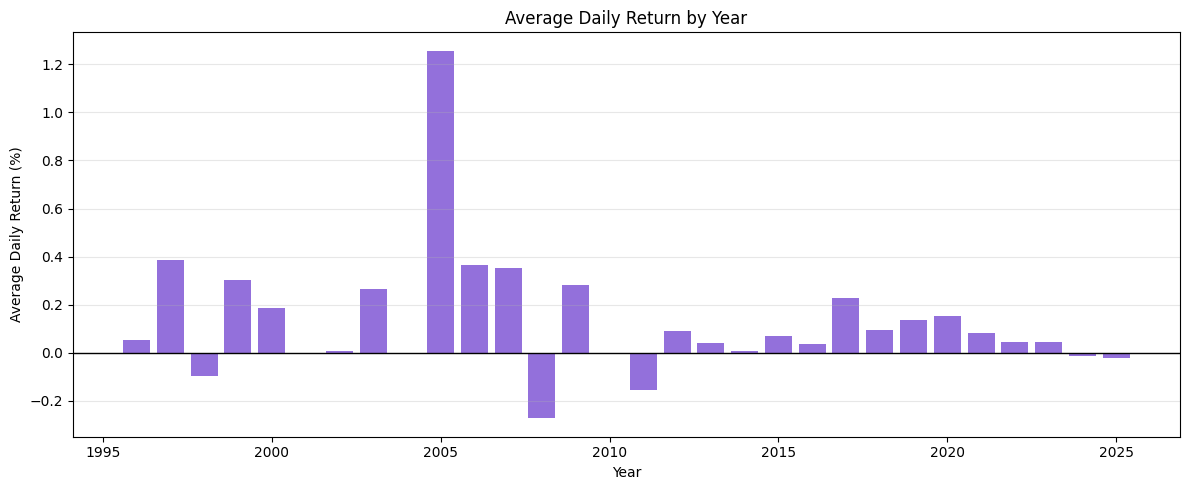

In [ ]:
df["year"] = df["date"].dt.year

yearly_return = df.groupby("year")["daily_return"].mean()

plt.figure(figsize=(12, 5))

plt.bar(
    yearly_return.index,
    yearly_return.values,
    color="mediumpurple"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Average Daily Return by Year")
plt.xlabel("Year")
plt.ylabel("Average Daily Return (%)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

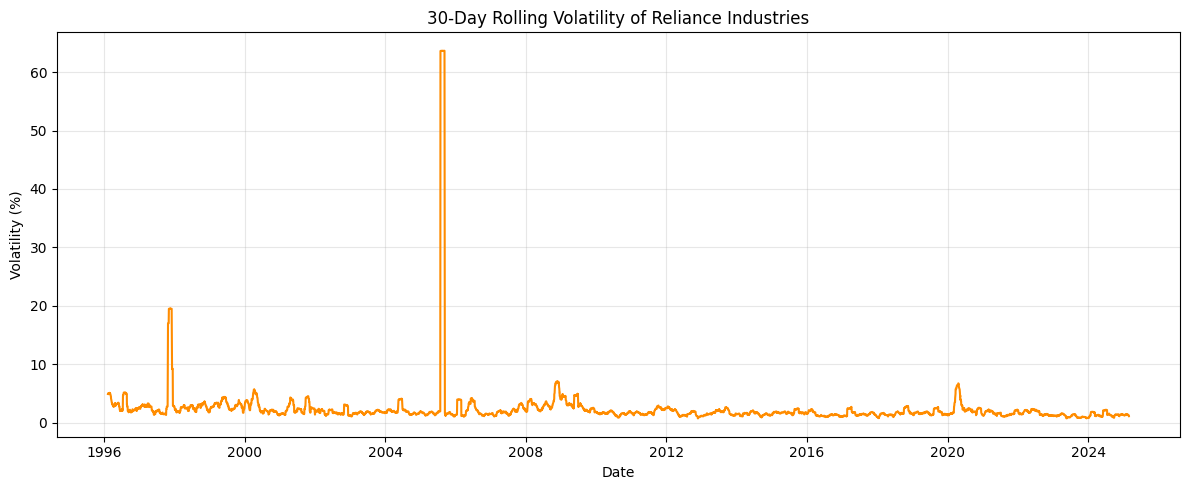

In [ ]:
df["rolling_volatility"] = df["daily_return"].rolling(30).std()

plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["rolling_volatility"],
    color="darkorange",
    linewidth=1.5
)

plt.title("30-Day Rolling Volatility of Reliance Industries")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("TASK 5 VISUALIZATION SUMMARY")
print("=" * 40)

print("Highest Closing Price:",
      round(df["close"].max(), 2))

print("Lowest Closing Price:",
      round(df["close"].min(), 2))

print("Average Closing Price:",
      round(df["close"].mean(), 2))

print("Highest Trading Volume:",
      int(df["volume"].max()))

print("Average Trading Volume:",
      int(df["volume"].mean()))

print("Average Daily Return:",
      round(df["daily_return"].mean(), 4), "%")

print("Daily Return Volatility:",
      round(df["daily_return"].std(), 4), "%")

print("Average 30-Day Rolling Volatility:",
      round(df["rolling_volatility"].mean(), 4), "%")

print("Maximum 30-Day Rolling Volatility:",
      round(df["rolling_volatility"].max(), 4), "%")

TASK 5 VISUALIZATION SUMMARY
Highest Closing Price: 1600.9
Lowest Closing Price: 5.49
Average Closing Price: 326.56
Highest Trading Volume: 1448889005
Average Trading Volume: 59381906
Average Daily Return: 0.1354 %
Daily Return Volatility: 4.7649 %
Average 30-Day Rolling Volatility: 2.3371 %
Maximum 30-Day Rolling Volatility: 63.6668 %


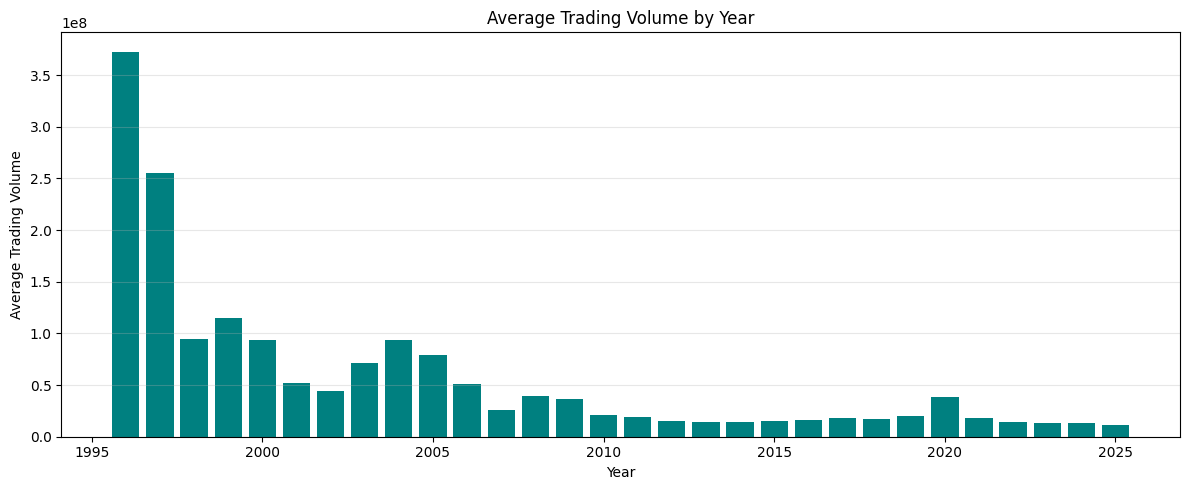

In [ ]:
yearly_volume = df.groupby("year")["volume"].mean()

plt.figure(figsize=(12, 5))

plt.bar(
    yearly_volume.index,
    yearly_volume.values,
    color="teal"
)

plt.title("Average Trading Volume by Year")
plt.xlabel("Year")
plt.ylabel("Average Trading Volume")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()